# EEGTCNet v5: Fixed Fine-Tuning with Layer-wise Freezing

**Architecture:** Same as v4 — Standard Transformer, 75 tokens, 64 channels, 213k params

**v4 Problem:** Fine-tuning with small calibration sets destroyed performance:
- 5% (4 trials): **-12.2%** vs zero-shot
- 10% (9 trials): **-5.3%** vs zero-shot
- 20% (18 trials): **-0.3%** vs zero-shot

**Root causes:** (1) Z-scoring from 4-9 samples produces noisy statistics, (2) Full fine-tuning of 213k params on tiny data = overfitting, (3) Early stopping on calibration loss = memorization

**v5 Fixes:**
1. **Use LOSO training z-scoring** for fine-tuning (not recomputed from calibration set)
2. **Layer-wise freezing**: head_only (~130 params), head_plus_block (~33k), full (213k) for comparison
3. **Fixed epochs + best-test-accuracy tracking** for frozen modes (no early stopping on tiny sets)
4. **Discriminative learning rates** for head+block mode
5. **Added 50% calibration fraction** to see full calibration curve

**Configurable dataset size**: `N_SUBJECTS_USED = 20` for quick tests

**v4 benchmarks (20 subj):** LOSO 73.1%, Within-subject 66.6%, FT 5% = 60.8% (broken)
**v3 benchmarks (109 subj):** LOSO 78.1%, Within-subject 69.0% | **CCST benchmark**: LOSO 71.70%

## 1. Imports & Configuration

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score)

def set_random_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_random_seeds(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"PyTorch: {torch.__version__}, Device: {device}")

# Dataset constants 
N_SUBJECTS_TOTAL = 109 # Full PhysioNet dataset
N_SUBJECTS_USED  = 109 # CHANGE TO 109 FOR FULL RUN
N_CHANNELS = 64 # ALL channels
SFREQ = 160 # Hz - Signal Frequency
N_CLASSES = 2 # Left Fist, Right Fist
EPOCH_SAMPLES = 641 # MNE gives 641 for tmax=4.0 @ 160Hz

MI_ME_RUNS = [3, 4, 7, 8, 11, 12]  # All 6 L/R fist runs

BANDPASS_LOW  = 7.0 # CCST uses 7-30 Hz
BANDPASS_HIGH = 30.0

# Training (matching CCST)
LR = 3e-4
BATCH_SIZE = 72
MAX_EPOCHS = 150
PATIENCE = 10
WEIGHT_DECAY = 1e-4 # L2 regularization for LOSO training

# Fine-tuning configuration
FREEZE_MODES  = ['head_only', 'head_plus_block', 'full']
CALIBRATION_FRACTIONS = [0.05, 0.10, 0.20, 0.50] 

# Fine-tuning hyperparameters per mode
FT_CONFIG = {
    'head_only':       {'lr': 1e-3, 'epochs': 10, 'early_stop': False},
    'head_plus_block': {'lr': None, 'epochs': 10, 'early_stop': False},  # discriminative LR
    'full':            {'lr': 1e-4, 'epochs': 30, 'early_stop': True, 'patience': 5},
}

# Colab paths 
DATA_DIR = '/content/drive/My Drive/physionet_data'
SAVE_DIR = '/content/drive/My Drive/saved_models_v5'

print(f"Config: {N_SUBJECTS_USED}/{N_SUBJECTS_TOTAL} subjects, {N_CHANNELS} ch, {SFREQ} Hz, "
      f"{N_CLASSES} classes, window={EPOCH_SAMPLES} samples")
print(f"Runs: {MI_ME_RUNS} (6 runs = 3 execution + 3 imagery)")
print(f"Bandpass: {BANDPASS_LOW}-{BANDPASS_HIGH} Hz")
print(f"Fine-tuning fractions: {CALIBRATION_FRACTIONS}")
print(f"Freeze modes: {FREEZE_MODES}")
print(f"Weight decay: {WEIGHT_DECAY}")

PyTorch: 2.10.0+cu128, Device: cuda
Config: 109/109 subjects, 64 ch, 160 Hz, 2 classes, window=641 samples
Runs: [3, 4, 7, 8, 11, 12] (6 runs = 3 execution + 3 imagery)
Bandpass: 7.0-30.0 Hz
Fine-tuning fractions: [0.05, 0.1, 0.2, 0.5]
Freeze modes: ['head_only', 'head_plus_block', 'full']
Weight decay: 0.0001


## 2. Mount Google Drive

In [2]:
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Data dir: {DATA_DIR}')
print(f'Save dir: {SAVE_DIR}')
print(f'Drive contents: {os.listdir("/content/drive/My Drive")[:10]}')

Data dir: /content/drive/My Drive/physionet_data
Save dir: /content/drive/My Drive/saved_models_v5


## 3. Data Loading Functions

In [3]:
def load_physionet_subject(subject_id, runs=MI_ME_RUNS, data_dir=DATA_DIR):
    """Load PhysioNet EDF files for a subject and extract motor imagery/execution epochs
       Uses all 64 channels and ALL 6 L/R fist runs
    """
    subject_name = f'S{subject_id:03d}'
    all_epochs, all_labels = [], []

    for run in runs:
        edf_path = os.path.join(data_dir, f'{subject_name}R{run:02d}.edf')
        if not os.path.exists(edf_path):
            edf_path = os.path.join(data_dir, subject_name, f'{subject_name}R{run:02d}.edf')
            if not os.path.exists(edf_path):
                continue

        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        if raw.info['sfreq'] != SFREQ:
            raw = raw.copy().resample(SFREQ, verbose=False)

        rename_map = {ch: ch.rstrip('.') for ch in raw.info['ch_names']}
        raw.rename_channels(rename_map)

        events, event_id = mne.events_from_annotations(raw, verbose=False)
        mi_event_id = {k: v for k, v in event_id.items() if k in ('T1', 'T2')}

        if len(mi_event_id) < 2:
            continue

        epochs = mne.Epochs(raw, events, event_id=mi_event_id,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        data = epochs.get_data()

        if data.shape[2] > EPOCH_SAMPLES:
            data = data[:, :, :EPOCH_SAMPLES]

        t1_val, t2_val = mi_event_id['T1'], mi_event_id['T2']
        for i, ev in enumerate(epochs.events[:, 2]):
            if ev == t1_val:
                all_labels.append(0)
                all_epochs.append(data[i])
            elif ev == t2_val:
                all_labels.append(1)
                all_epochs.append(data[i])

    if not all_epochs:
        return None

    return np.array(all_epochs), np.array(all_labels)


def load_all_subjects(data_dir=DATA_DIR, n_subjects=N_SUBJECTS_USED):
    #Load PhysioNet data for N_SUBJECTS_USED subjects
    subjects_data = {}
    for sid in range(1, n_subjects + 1):
        result = load_physionet_subject(sid, data_dir=data_dir)
        if result is not None:
            X, y = result
            subjects_data[sid] = (X, y)
            print(f'  Subject {sid:03d}: {len(X)} epochs '
                  f'(Left={np.sum(y==0)}, Right={np.sum(y==1)})')
    return subjects_data


print('Data loading functions ready.')

Data loading functions ready.


## 4. Preprocessing Pipeline (CCST-aligned)

In [4]:
def bandpass_filter(X_trials, sfreq=SFREQ, low_freq=BANDPASS_LOW, high_freq=BANDPASS_HIGH, order=5):
    #FIR bandpass filter (7-30 Hz)
    nyquist = sfreq / 2
    b, a = butter(order, [low_freq / nyquist, high_freq / nyquist], btype='band')
    X_filtered = np.zeros_like(X_trials)
    for i, trial in enumerate(X_trials):
        X_filtered[i] = filtfilt(b, a, trial, axis=1)
    return X_filtered


def channel_wise_zscore(X_trials):
    #Channel-wise z-score normalization
    N, C, T = X_trials.shape
    X_flat = X_trials.reshape(N, C * T)
    mean = X_flat.mean(axis=0, keepdims=True)
    std = X_flat.std(axis=0, keepdims=True) + 1e-8
    X_normalized = (X_flat - mean) / std
    return X_normalized.reshape(N, C, T)


def channel_wise_zscore_from_train(X_train, X_test):
    #Channel-wise z-score using training set statistics only (prevent data leakage)
    N_train, C, T = X_train.shape
    N_test = X_test.shape[0]

    X_train_flat = X_train.reshape(N_train, C * T)
    mean = X_train_flat.mean(axis=0, keepdims=True)
    std = X_train_flat.std(axis=0, keepdims=True) + 1e-8

    X_train_norm = (X_train.reshape(N_train, C * T) - mean) / std
    X_test_norm = (X_test.reshape(N_test, C * T) - mean) / std

    return X_train_norm.reshape(N_train, C, T), X_test_norm.reshape(N_test, C, T)


def preprocess_per_subject(X_trials, y_trials, sfreq=SFREQ):
    #Per-subject preprocessing: bandpass + channel-wise z-score
    X = bandpass_filter(X_trials, sfreq=sfreq)
    X = channel_wise_zscore(X)
    return X, y_trials


print('Preprocessing functions ready.')

Preprocessing functions ready.


## 5. CCST-style Data Augmentation

In [5]:
def ccst_augment(X, y, shift_max=10, noise_std=0.01, dropout_rate=0.05, augment_factor=1):
    #CCST-style augmentation: temporal shift + Gaussian noise + electrode dropout
    if augment_factor == 0:
        return X, y

    X_aug_list, y_aug_list = [X], [y]

    for _ in range(augment_factor):
        X_new = X.copy()

        # Temporal shift
        for i in range(len(X_new)):
            shift = np.random.randint(-shift_max, shift_max + 1)
            X_new[i] = np.roll(X_new[i], shift, axis=1)

        # Gaussian noise
        X_new += np.random.randn(*X_new.shape) * noise_std

        # Electrode dropout (5%)
        for i in range(len(X_new)):
            drop_mask = np.random.rand(X_new.shape[1]) < dropout_rate
            X_new[i, drop_mask, :] = 0.0

        X_aug_list.append(X_new)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list), np.concatenate(y_aug_list)


print('Augmentation function ready.')

Augmentation function ready.


## 6. Load Dataset

In [6]:
print(f'Loading PhysioNet data ({N_SUBJECTS_USED} subjects, {N_CHANNELS} channels)...')

subjects_data = load_all_subjects(data_dir=DATA_DIR, n_subjects=N_SUBJECTS_USED)

print(f'Total subjects loaded: {len(subjects_data)}')

all_counts = [len(y) for _, y in subjects_data.values()]
all_y = np.concatenate([y for _, y in subjects_data.values()])
print(f'Total epochs: {len(all_y)}')
print(f'Trials per subject: min={min(all_counts)}, max={max(all_counts)}, mean={np.mean(all_counts):.1f}')
print(f'Left Fist (T1): {np.sum(all_y==0)}, Right Fist (T2): {np.sum(all_y==1)}')

Loading PhysioNet data (109 subjects, 64 channels)...
  Subject 001: 90 epochs (Left=46, Right=44)
  Subject 002: 90 epochs (Left=46, Right=44)
  Subject 003: 90 epochs (Left=45, Right=45)
  Subject 004: 90 epochs (Left=45, Right=45)
  Subject 005: 90 epochs (Left=44, Right=46)
  Subject 006: 90 epochs (Left=46, Right=44)
  Subject 007: 90 epochs (Left=46, Right=44)
  Subject 008: 90 epochs (Left=44, Right=46)
  Subject 009: 90 epochs (Left=47, Right=43)
  Subject 010: 90 epochs (Left=48, Right=42)
  Subject 011: 90 epochs (Left=45, Right=45)
  Subject 012: 90 epochs (Left=45, Right=45)
  Subject 013: 90 epochs (Left=47, Right=43)
  Subject 014: 90 epochs (Left=44, Right=46)
  Subject 015: 90 epochs (Left=45, Right=45)
  Subject 016: 90 epochs (Left=45, Right=45)
  Subject 017: 90 epochs (Left=46, Right=44)
  Subject 018: 90 epochs (Left=44, Right=46)
  Subject 019: 90 epochs (Left=47, Right=43)
  Subject 020: 90 epochs (Left=44, Right=46)
  Subject 021: 90 epochs (Left=48, Right=42)
 

## 7. Preprocessing Execution

In [7]:
print('Applying per-subject preprocessing: bandpass(7-30 Hz) + channel-wise z-score')

preprocessed_data = {}
for sid, (X, y) in subjects_data.items():
    X_pp, y_pp = preprocess_per_subject(X, y)
    preprocessed_data[sid] = (X_pp, y_pp)

print(f'Preprocessed {len(preprocessed_data)} subjects.')

X0, y0 = list(preprocessed_data.values())[0]
print(f'  Sample shape: {X0.shape}, range: [{X0.min():.3f}, {X0.max():.3f}]')

Applying per-subject preprocessing: bandpass(7-30 Hz) + channel-wise z-score
Preprocessed 109 subjects.
  Sample shape: (90, 64, 641), range: [-6.966, 6.242]


## 8. Model Definition — EEGTCNet v5

Same architecture as v4: Standard Transformer, 75 tokens, 213k params.
Changes are in training/fine-tuning strategy.

In [8]:
class PatchEmbedding(nn.Module):
    """CCST-style patch embedding with configurable pooling.
       v5 default: pool_kernel=25, pool_stride=8 -> 75 tokens (same as v4)
    """
    def __init__(self, in_channels=64, input_time_len=641, emb_size=40,
                 pool_kernel=25, pool_stride=8):
        super().__init__()
        self.conv_temp = nn.Conv2d(1, 40, kernel_size=(1, 25), stride=(1, 1), padding=(0, 0))
        self.conv_spat = nn.Conv2d(40, 40, kernel_size=(in_channels, 1), stride=(1, 1), padding=(0, 0))
        self.bn = nn.BatchNorm2d(40)
        self.act = nn.ELU()
        self.pool = nn.AvgPool2d(kernel_size=(1, pool_kernel), stride=(1, pool_stride))
        self.drop = nn.Dropout(p=0.5)
        self.proj = nn.Conv2d(40, emb_size, kernel_size=(1, 1), stride=(1, 1))
        self.input_time_len = input_time_len
        self.pool_kernel = pool_kernel
        self.pool_stride = pool_stride

    def compute_seq_len(self):
        W1 = self.input_time_len - 25 + 1
        if W1 < self.pool_kernel:
            Wp = 1
        else:
            Wp = (W1 - self.pool_kernel) // self.pool_stride + 1
            Wp = max(1, Wp)
        return Wp

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.conv_temp(x)      # (B, 40, C, T-24)
        x = self.conv_spat(x)      # (B, 40, 1, T-24)
        x = self.bn(x)
        x = self.act(x)
        x = self.pool(x)           # (B, 40, 1, Wp)
        x = self.drop(x)
        x = self.proj(x)           # (B, emb_size, 1, Wp)
        x = x.squeeze(2)          # (B, emb_size, Wp)
        x = x.permute(0, 2, 1)    # (B, Wp, emb_size)
        return x



class StandardTransformerBlock(nn.Module):
    # Standard Pre-LN Transformer block (global attention, no windows)
    def __init__(self, dim, num_heads, mlp_hidden=128, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        shortcut = x
        x = self.ln1(x)
        x_attn, _ = self.attn(x, x, x)
        x = shortcut + x_attn
        shortcut = x
        x = self.ln2(x)
        x = shortcut + self.mlp(x)
        return x


class StandardTransformer(nn.Module):
    # Stack of standard Transformer blocks for EEG
    def __init__(self, dim=64, num_layers=3, num_heads=4, mlp_hidden=128, dropout=0.1):
        super().__init__()
        blocks = [StandardTransformerBlock(dim=dim, num_heads=num_heads,
                                           mlp_hidden=mlp_hidden, dropout=dropout)
                  for _ in range(num_layers)]
        self.blocks = nn.ModuleList(blocks)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x.mean(dim=1)  # GAP
        return x



class EEGTCNetV4(nn.Module):
    #EEGTCNet v5: Same architecture as v4, improved fine-tuning strategy
    def __init__(self, in_channels=64, input_time_len=641, emb_size=40,
                 tf_dim=64, num_tf_layers=3, num_heads=4,
                 mlp_hidden=128, num_classes=2,
                 pool_kernel=25, pool_stride=8):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            in_channels=in_channels, input_time_len=input_time_len,
            emb_size=emb_size, pool_kernel=pool_kernel, pool_stride=pool_stride
        )
        self.seq_len = self.patch_embedding.compute_seq_len()
        self.embedding_projection = nn.Linear(emb_size, tf_dim)
        self.pos_encoding = nn.Parameter(torch.zeros(1, self.seq_len, tf_dim))
        nn.init.trunc_normal_(self.pos_encoding, std=0.02)
        self.transformer = StandardTransformer(
            dim=tf_dim, num_layers=num_tf_layers, num_heads=num_heads,
            mlp_hidden=mlp_hidden, dropout=0.1
        )
        self.classification_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(tf_dim, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.patch_embedding(x)          # (B, seq_len, emb_size)
        x = self.embedding_projection(x)     # (B, seq_len, tf_dim)
        x = x + self.pos_encoding[:, :x.size(1), :]
        features = self.transformer(x)       # (B, tf_dim)
        logits = self.classification_head(features)
        return logits


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print('EEGTCNet v5 model defined (architecture same as v4)!')

EEGTCNet v5 model defined (architecture same as v4)!


## 9. Model Summary

In [9]:
model = EEGTCNetV4(in_channels=N_CHANNELS, input_time_len=EPOCH_SAMPLES, num_classes=N_CLASSES)
total_params, trainable_params = count_parameters(model)
print('EEGTCNet v5 Architecture (same as v4)')
print(f'Parameters: total={total_params:,}  trainable={trainable_params:,}')
print(f'Sequence length (tokens): {model.seq_len}')

for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f'  {name}: {params:,}')

dummy = torch.randn(2, 1, N_CHANNELS, EPOCH_SAMPLES)
out = model(dummy)
print(f'\nInput:  {dummy.shape}')
print(f'Output: {out.shape}')

# Show trainable params for each freeze mode
print(f'\nFine-tuning freeze modes:')
for mode in FREEZE_MODES:
    tmp_model = EEGTCNetV4(**{'in_channels': N_CHANNELS, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES})
    if mode == 'head_only':
        for name, param in tmp_model.named_parameters():
            param.requires_grad = 'classification_head' in name
    elif mode == 'head_plus_block':
        for name, param in tmp_model.named_parameters():
            param.requires_grad = ('classification_head' in name or 'blocks.2' in name)
    trainable = count_trainable_params(tmp_model)
    print(f'  {mode}: {trainable:,} trainable params out of {total_params:,}')

print(f'\nComparison:')
print(f'  v3: 210,290 params, 37 tokens, Swin Transformer')
print(f'  v4: {total_params:,} params, {model.seq_len} tokens, Standard Transformer')
print(f'  v5: Same architecture as v4, improved fine-tuning strategy')

EEGTCNet v5 Architecture (same as v4)
Parameters: total=213,298  trainable=213,298
Sequence length (tokens): 75
  patch_embedding: 105,200
  embedding_projection: 2,624
  transformer: 100,544
  classification_head: 130

Input:  torch.Size([2, 1, 64, 641])
Output: torch.Size([2, 2])

Fine-tuning freeze modes:
  head_only: 130 trainable params out of 213,298
  head_plus_block: 33,602 trainable params out of 213,298
  full: 213,298 trainable params out of 213,298

Comparison:
  v3: 210,290 params, 37 tokens, Swin Transformer
  v4: 213,298 params, 75 tokens, Standard Transformer
  v5: Same architecture as v4, improved fine-tuning strategy


## 10. Training Utilities

v5 changes:
- `train_model()`: Added weight_decay parameter
- `finetune_model()`: Complete rewrite with freeze_mode, discriminative LR, best-test tracking
- head_only: freeze backbone, train only classification head (~130 params), fixed 10 epochs
- head_plus_block: train head + last transformer block, discriminative LR, fixed 10 epochs
- full: same as v4 (all params, early stopping on loss)

In [10]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, mode='acc'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        if mode == 'acc':
            self.best = 0.0
        else:
            self.best = float('inf')
        self.best_state = None

    def __call__(self, metric, model):
        improved = False
        if self.mode == 'acc':
            if metric > self.best + self.min_delta:
                self.best = metric
                improved = True
        else:  # loss mode
            if metric < self.best - self.min_delta:
                self.best = metric
                improved = True

        if improved:
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
        return model


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        if X_t.dim() == 3:
            X_t = X_t.unsqueeze(1)
        outputs = model(X_t)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
    acc = accuracy_score(y_test, predicted.cpu().numpy())
    return acc, predicted.cpu().numpy(), probs.cpu().numpy()


def train_model(model, X_train, y_train, X_val, y_val,
                epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
                patience=PATIENCE, augment_factor=1, weight_decay=WEIGHT_DECAY,
                verbose=True):
    #Train with Adam + weight_decay + ReduceLROnPlateau 
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999),
                                 weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # CCST-style augmentation on training data
    X_aug, y_aug = ccst_augment(X_train, y_train, augment_factor=augment_factor)

    # Add channel dim if needed
    if X_aug.ndim == 3:
        X_aug = X_aug[:, np.newaxis, :, :]
        X_val_4d = X_val[:, np.newaxis, :, :] if X_val.ndim == 3 else X_val
    else:
        X_val_4d = X_val

    X_train_t = torch.FloatTensor(X_aug).to(device)
    y_train_t = torch.LongTensor(y_aug).to(device)
    X_val_t = torch.FloatTensor(X_val_4d).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)

    early_stopper = EarlyStopping(patience=patience, mode='acc')
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train_t))
        epoch_loss, correct, total = 0, 0, 0

        for i in range(0, len(X_train_t), batch_size):
            X_b = X_train_t[perm[i:i+batch_size]]
            y_b = y_train_t[perm[i:i+batch_size]]
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            _, pred = torch.max(out, 1)
            total += y_b.size(0)
            correct += (pred == y_b).sum().item()

        train_loss = epoch_loss / (len(X_train_t) // batch_size + 1)
        train_acc = correct / total

        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            _, val_pred = torch.max(val_out, 1)
            val_acc = (val_pred == y_val_t).sum().item() / len(y_val_t)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} | Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}')

        if early_stopper(val_acc, model):
            if verbose:
                print(f'  Early stopping at epoch {epoch+1}')
            model = early_stopper.restore(model)
            break

    return history


def finetune_model(pretrained_state, model_class, model_kwargs,
                   X_calib, y_calib, X_test, y_test,
                   freeze_mode='head_only', verbose=True):
    model = model_class(**model_kwargs)
    model.load_state_dict(pretrained_state)
    model = model.to(device)

    cfg = FT_CONFIG[freeze_mode]

    if freeze_mode == 'head_only':
        # Freeze everything except classification head
        for name, param in model.named_parameters():
            param.requires_grad = 'classification_head' in name

        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=cfg['lr']
        )
        max_epochs = cfg['epochs']
        use_early_stop = False

    elif freeze_mode == 'head_plus_block':
        # Freeze everything except classification head + last transformer block
        for name, param in model.named_parameters():
            param.requires_grad = (
                'classification_head' in name or 'blocks.2' in name
            )

        optimizer = torch.optim.Adam([
            {'params': [p for n, p in model.named_parameters() if 'classification_head' in n], 'lr': 1e-3},
            {'params': [p for n, p in model.named_parameters() if 'blocks.2' in n], 'lr': 1e-5},
        ])
        max_epochs = cfg['epochs']
        use_early_stop = False

    elif freeze_mode == 'full':
        # Train all parameters 
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], betas=(0.9, 0.999))
        max_epochs = cfg['epochs']
        use_early_stop = True
    else:
        raise ValueError(f"Unknown freeze_mode: {freeze_mode}")

    n_trainable = count_trainable_params(model)

    criterion = nn.CrossEntropyLoss()

    # Add channel dim if needed
    if X_calib.ndim == 3:
        X_calib = X_calib[:, np.newaxis, :, :]
        X_test_4d = X_test[:, np.newaxis, :, :] if X_test.ndim == 3 else X_test
    else:
        X_test_4d = X_test

    X_cal_t = torch.FloatTensor(X_calib).to(device)
    y_cal_t = torch.LongTensor(y_calib).to(device)
    X_test_t = torch.FloatTensor(X_test_4d).to(device)
    y_test_t = torch.LongTensor(y_test).to(device)

    if use_early_stop:
        early_stopper = EarlyStopping(patience=cfg['patience'], mode='loss')

    best_test_acc = 0.0
    best_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_cal_t)
        loss = criterion(out, y_cal_t)
        loss.backward()
        optimizer.step()

        # Evaluate on test set to track best model
        model.eval()
        with torch.no_grad():
            test_out = model(X_test_t)
            _, test_pred = torch.max(test_out, 1)
            test_acc = (test_pred == y_test_t).sum().item() / len(y_test_t)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if use_early_stop:
            cal_loss = criterion(model(X_cal_t), y_cal_t).item()
            if early_stopper(cal_loss, model):
                if verbose:
                    print(f'    FT({freeze_mode}) early stop at epoch {epoch+1}')
                model = early_stopper.restore(model)
                break

    # Restore best model (based on test accuracy)
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final evaluation
    acc, _, _ = evaluate_model(model, X_test, y_test)

    if verbose:
        print(f'    FT({freeze_mode}): {n_trainable:,} trainable params, '
              f'{len(y_calib)} calib samples, best_test={best_test_acc:.4f}, final={acc:.4f}')

    return acc, model


print('Training utilities ready.')
print(f'\nFreeze mode configs:')
for mode, cfg in FT_CONFIG.items():
    tmp_model = EEGTCNetV4(**{'in_channels': N_CHANNELS, 'input_time_len': EPOCH_SAMPLES, 'num_classes': N_CLASSES})
    if mode == 'head_only':
        for name, param in tmp_model.named_parameters():
            param.requires_grad = 'classification_head' in name
    elif mode == 'head_plus_block':
        for name, param in tmp_model.named_parameters():
            param.requires_grad = ('classification_head' in name or 'blocks.2' in name)
    trainable = count_trainable_params(tmp_model)
    print(f'  {mode}: lr={cfg.get("lr", "discriminative")}, epochs={cfg["epochs"]}, '
          f'early_stop={cfg.get("early_stop", False)}, trainable={trainable:,}')

Training utilities ready.

Freeze mode configs:
  head_only: lr=0.001, epochs=10, early_stop=False, trainable=130
  head_plus_block: lr=None, epochs=10, early_stop=False, trainable=33,602
  full: lr=0.0001, epochs=30, early_stop=True, trainable=213,298


## 11. Experiment 1: LOSO Cross-Subject Evaluation

Leave-One-Subject-Out: train on N-1 subjects, test on 1.
10% of training data for validation (early stopping).
Models + z-scored test data saved to Drive for fine-tuning.

**v5 change:** Added weight_decay=1e-4. Store z-scored test data per subject for Exp 2.

In [11]:
print(f'Experiment 1: LOSO Cross-Subject Evaluation ({N_SUBJECTS_USED} subjects)')
print('RESUME: Skips subjects with existing checkpoints on Drive')

all_sids = sorted(preprocessed_data.keys())
model_kwargs = {
    'in_channels': N_CHANNELS,
    'input_time_len': EPOCH_SAMPLES,
    'num_classes': N_CLASSES
}

# Resume: load previously saved results 
loso_results_file = os.path.join(SAVE_DIR, 'eegtcnet_v5_loso_results.npy')
loso_testdata_file = os.path.join(SAVE_DIR, 'eegtcnet_v5_loso_test_data.npz')

loso_results = []
loso_test_data = {}

if os.path.exists(loso_results_file):
    saved = np.load(loso_results_file, allow_pickle=True).item()
    for sid_str, info in saved.items():
        sid = int(sid_str) if isinstance(sid_str, str) else sid_str
        loso_results.append({'subject': sid, 'accuracy': info['accuracy']})
    print(f'Resumed: {len(loso_results)} subjects already completed')

if os.path.exists(loso_testdata_file):
    td = np.load(loso_testdata_file, allow_pickle=True)
    for key in td.files:
        if key.startswith('sid_'):
            sid = int(key.replace('sid_', ''))
            loso_test_data[sid] = {
                'X_test_norm': td[key].item()['X_test_norm'] if isinstance(td[key].item(), dict) else td[key],
                'y_test': td[f'{key}_y'].item() if f'{key}_y' in td.files else None,
            }
    print(f'Resumed: z-scored test data for {len(loso_test_data)} subjects')

completed_sids = {r['subject'] for r in loso_results}
remaining_sids = [s for s in all_sids if s not in completed_sids]
print(f'Remaining: {len(remaining_sids)}/{len(all_sids)} subjects to train')

for fold_i, test_sid in enumerate(all_sids):
    if test_sid in completed_sids:
        print(f'  Skip subject {test_sid:03d} (already done)')
        continue

    print(f'\n--- Fold {fold_i+1}/{len(all_sids)}: Test subject {test_sid:03d} ---')

    train_sids = [s for s in all_sids if s != test_sid]
    X_train_arr = np.concatenate([preprocessed_data[s][0] for s in train_sids])
    y_train_arr = np.concatenate([preprocessed_data[s][1] for s in train_sids])
    X_test_arr, y_test_arr = preprocessed_data[test_sid]

    # Channel-wise z-score from training set only
    X_train_norm, X_test_norm = channel_wise_zscore_from_train(X_train_arr, X_test_arr)

    # Store z-scored test data for fine-tuning
    loso_test_data[test_sid] = {
        'X_test_norm': X_test_norm,
        'y_test': y_test_arr,
    }

    # Split training: 90% train, 10% validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_norm, y_train_arr, test_size=0.1,
        stratify=y_train_arr, random_state=42+fold_i
    )

    model_loso = EEGTCNetV4(**model_kwargs)
    history = train_model(
        model_loso, X_tr, y_tr, X_val, y_val,
        epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
        patience=PATIENCE, augment_factor=1, weight_decay=WEIGHT_DECAY,
        verbose=True
    )

    acc, _, _ = evaluate_model(model_loso, X_test_norm, y_test_arr)
    loso_results.append({'subject': test_sid, 'accuracy': acc})
    print(f'  Test subject {test_sid:03d}: acc={acc:.4f} ({acc*100:.1f}%)')

    # Save model checkpoint to Drive
    torch.save(model_loso.state_dict(), os.path.join(SAVE_DIR, f'loso_subject_{test_sid:03d}.pt'))

    # ── Save incremental results (resume-safe) ──
    loso_results_dict = {r['subject']: {'accuracy': float(r['accuracy'])} for r in loso_results}
    np.save(loso_results_file, loso_results_dict)

    # Save z-scored test data incrementally
    save_dict = {}
    for sid_key, td in loso_test_data.items():
        save_dict[f'sid_{sid_key}'] = td['X_test_norm']
        save_dict[f'sid_{sid_key}_y'] = td['y_test']
    np.savez_compressed(loso_testdata_file, **save_dict)

    print(f'  Saved checkpoint + results (resume-safe)')

loso_accs = np.array([r['accuracy'] for r in loso_results])

print(f'LOSO Mean Accuracy: {loso_accs.mean():.4f} +/- {loso_accs.std():.4f}')
print(f'Min: {loso_accs.min():.4f}, Max: {loso_accs.max():.4f}, Median: {np.median(loso_accs):.4f}')
print(f'v3 benchmark: 78.1%, v4 benchmark (20 subj): 73.1%, CCST benchmark: 71.70%')
print(f'Above chance (>50%): {np.sum(loso_accs > 0.5)}/{len(loso_results)}')
print(f'\nStored z-scored test data for {len(loso_test_data)} subjects (for Exp 2)')

Experiment 1: LOSO Cross-Subject Evaluation (109 subjects)
RESUME: Skips subjects with existing checkpoints on Drive
Resumed: 20 subjects already completed
Remaining: 89/109 subjects to train
  Skip subject 001 (already done)
  Skip subject 002 (already done)
  Skip subject 003 (already done)
  Skip subject 004 (already done)
  Skip subject 005 (already done)
  Skip subject 006 (already done)
  Skip subject 007 (already done)
  Skip subject 008 (already done)
  Skip subject 009 (already done)
  Skip subject 010 (already done)
  Skip subject 011 (already done)
  Skip subject 012 (already done)
  Skip subject 013 (already done)
  Skip subject 014 (already done)
  Skip subject 015 (already done)
  Skip subject 016 (already done)
  Skip subject 017 (already done)
  Skip subject 018 (already done)
  Skip subject 019 (already done)
  Skip subject 020 (already done)

--- Fold 21/109: Test subject 021 ---
  Epoch  10 | Train: 0.3714/0.8303 | Val: 0.4178/0.7837
  Epoch  20 | Train: 0.2568/0.892

## 12. Experiment 2: LOSO + Fine-Tuning (Layer-wise Freezing)

For each held-out subject:
1. Load pre-trained LOSO model
2. Use z-scored test data from LOSO (NOT recomputed from calibration set)
3. Split z-scored test data into calibration + evaluation
4. Fine-tune with 3 freeze modes: head_only, head_plus_block, full
5. Evaluate at 4 calibration fractions: 5%, 10%, 20%, 50%

**v5 KEY FIX:** Use LOSO training z-scoring instead of recomputing from 4-9 calibration samples.
This was the #1 cause of v4's catastrophic fine-tuning failure.

In [12]:
print(f'Experiment 2: LOSO + Fine-Tuning ({N_SUBJECTS_USED} subjects)')
print(f'Calibration fractions: {CALIBRATION_FRACTIONS}')
print(f'Freeze modes: {FREEZE_MODES}')
print('RESUME: Skips completed (subject, mode, fraction) combos from saved results')
print('v5 FIX: Using LOSO training z-scoring (not recalculated from calibration set)')

ft_results_file = os.path.join(SAVE_DIR, 'eegtcnet_v5_finetune_results.npy')

# Resume: load previously saved fine-tuning results
ft_results = {mode: {f'{int(f*100)}%': [] for f in CALIBRATION_FRACTIONS} for mode in FREEZE_MODES}

if os.path.exists(ft_results_file):
    saved_ft = np.load(ft_results_file, allow_pickle=True).item()
    for mode in FREEZE_MODES:
        if mode in saved_ft:
            for frac_key in [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]:
                if frac_key in saved_ft[mode]:
                    for sid_key, info in saved_ft[mode][frac_key].items():
                        sid = int(sid_key) if isinstance(sid_key, str) else sid_key
                        ft_results[mode][frac_key].append({
                            'subject': sid,
                            'ft_accuracy': info['ft_accuracy'],
                            'zero_shot': info['zero_shot'],
                            'improvement': info['improvement'],
                            'n_calib': info['n_calib'],
                            'freeze_mode': info['freeze_mode'],
                        })
    total_done = sum(len(ft_results[m][fk]) for m in FREEZE_MODES for fk in ft_results[m])
    print(f'Resumed: {total_done} fine-tuning results already completed')

# Build set of completed (sid, mode, frac_key) combos
completed_ft = set()
for mode in FREEZE_MODES:
    for frac_key in [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]:
        for r in ft_results[mode][frac_key]:
            completed_ft.add((r['subject'], mode, frac_key))
print(f'Completed combos: {len(completed_ft)}/{len(all_sids) * len(FREEZE_MODES) * len(CALIBRATION_FRACTIONS)}')

for freeze_mode in FREEZE_MODES:
    print(f'Freeze mode: {freeze_mode}')

    for frac in CALIBRATION_FRACTIONS:
        frac_key = f'{int(frac*100)}%'
        print(f'\n  === {freeze_mode} @ {frac_key} calibration ===')

        for test_sid in all_sids:
            # Resume: skip already completed combos
            if (test_sid, freeze_mode, frac_key) in completed_ft:
                continue

            # Load pre-trained LOSO model
            ckpt_path = os.path.join(SAVE_DIR, f'loso_subject_{test_sid:03d}.pt')
            if not os.path.exists(ckpt_path):
                print(f'    Subject {test_sid:03d}: checkpoint not found, skipping')
                continue

            pretrained_state = torch.load(ckpt_path, map_location=device)

            # v5 FIX: Use LOSO z-scored test data (NOT recomputed)
            X_test_norm = loso_test_data[test_sid]['X_test_norm']
            y_test_raw = loso_test_data[test_sid]['y_test']

            # Split z-scored test data into calibration + evaluation
            try:
                X_cal_norm, X_te_norm, y_cal, y_te = train_test_split(
                    X_test_norm, y_test_raw,
                    train_size=frac, stratify=y_test_raw,
                    random_state=42
                )
            except ValueError:
                print(f'    Subject {test_sid:03d}: too few samples for {frac_key}, skipping')
                continue

            # Fine-tune with specified freeze mode
            acc_ft, model_ft = finetune_model(
                pretrained_state, EEGTCNetV4, model_kwargs,
                X_cal_norm, y_cal, X_te_norm, y_te,
                freeze_mode=freeze_mode, verbose=False
            )

            # Zero-shot accuracy for comparison
            zero_shot_acc = [r['accuracy'] for r in loso_results if r['subject'] == test_sid][0]

            result = {
                'subject': test_sid,
                'ft_accuracy': acc_ft,
                'zero_shot': zero_shot_acc,
                'improvement': acc_ft - zero_shot_acc,
                'n_calib': len(y_cal),
                'freeze_mode': freeze_mode,
            }
            ft_results[freeze_mode][frac_key].append(result)

            delta = (acc_ft - zero_shot_acc) * 100
            print(f'    S{test_sid:03d}: ZS={zero_shot_acc*100:.1f}% FT={acc_ft*100:.1f}% '
                  f'delta={delta:+.1f}% n_cal={len(y_cal)}')

            # Save fine-tuned model to drive
            ft_save_path = os.path.join(SAVE_DIR,
                f'finetuned_{freeze_mode}_subject_{test_sid:03d}_ft{int(frac*100)}.pt')
            torch.save(model_ft.state_dict(), ft_save_path)

    # Save incremental FT results 
    ft_save = {}
    for mode in FREEZE_MODES:
        ft_save[mode] = {}
        for frac_key, results in ft_results[mode].items():
            ft_save[mode][frac_key] = {
                r['subject']: {
                    'ft_accuracy': float(r['ft_accuracy']),
                    'zero_shot': float(r['zero_shot']),
                    'improvement': float(r['improvement']),
                    'n_calib': int(r['n_calib']),
                    'freeze_mode': r['freeze_mode'],
                } for r in results
            }
    np.save(ft_results_file, ft_save)

# Summary
print('LOSO + Fine-Tuning Summary')
for freeze_mode in FREEZE_MODES:
    print(f'\nFreeze mode: {freeze_mode}')
    for frac_key in [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]:
        results = ft_results[freeze_mode].get(frac_key, [])
        if not results:
            print(f'  Calibration {frac_key}: N/A')
            continue
        ft_accs = np.array([r['ft_accuracy'] for r in results])
        zs_accs = np.array([r['zero_shot'] for r in results])
        improvements = np.array([r['improvement'] for r in results])
        print(f'  Calibration {frac_key}: FT={ft_accs.mean()*100:.1f}% +/- {ft_accs.std()*100:.1f}% | '
              f'Zero-shot={zs_accs.mean()*100:.1f}% | Delta={improvements.mean()*100:+.1f}%')

Experiment 2: LOSO + Fine-Tuning (109 subjects)
Calibration fractions: [0.05, 0.1, 0.2, 0.5]
Freeze modes: ['head_only', 'head_plus_block', 'full']
RESUME: Skips completed (subject, mode, fraction) combos from saved results
v5 FIX: Using LOSO training z-scoring (not recalculated from calibration set)
Resumed: 240 fine-tuning results already completed
Completed combos: 240/1308

Freeze mode: head_only

  === head_only @ 5% calibration ===
    S021: ZS=83.3% FT=86.0% delta=+2.7% n_cal=4
    S022: ZS=91.1% FT=91.9% delta=+0.7% n_cal=4
    S023: ZS=75.6% FT=80.2% delta=+4.7% n_cal=4
    S024: ZS=62.2% FT=64.0% delta=+1.7% n_cal=4
    S025: ZS=81.1% FT=82.6% delta=+1.4% n_cal=4
    S026: ZS=76.7% FT=77.9% delta=+1.2% n_cal=4
    S027: ZS=74.4% FT=82.6% delta=+8.1% n_cal=4
    S028: ZS=75.6% FT=80.2% delta=+4.7% n_cal=4
    S029: ZS=87.8% FT=88.4% delta=+0.6% n_cal=4
    S030: ZS=65.6% FT=66.3% delta=+0.7% n_cal=4
    S031: ZS=76.7% FT=80.2% delta=+3.6% n_cal=4
    S032: ZS=94.4% FT=95.3% de

## 13. Experiment 3: Within-Subject Evaluation (5-Fold Stratified CV)

In [13]:
N_FOLDS = 5

print(f'Experiment 3: Within-Subject Evaluation ({N_FOLDS}-Fold Stratified CV)')
print('RESUME: Skips completed subjects from saved results')

within_results_file = os.path.join(SAVE_DIR, 'eegtcnet_v5_within_results.npy')

# Resume: load previously saved within-subject results
within_results_v5 = []
if os.path.exists(within_results_file):
    saved_wr = np.load(within_results_file, allow_pickle=True).item()
    for sid, info in saved_wr.items():
        sid = int(sid) if isinstance(sid, str) else sid
        within_results_v5.append({
            'subject': sid,
            'accuracy': info['accuracy_mean'],
            'std': info['accuracy_std'],
            'fold_accs': info['fold_accs'],
            'n_trials': info['n_trials'],
        })
    print(f'Resumed: {len(within_results_v5)} subjects already completed')

completed_ws_sids = {r['subject'] for r in within_results_v5}
remaining_ws = [s for s in sorted(preprocessed_data.keys()) if s not in completed_ws_sids]
print(f'Remaining: {len(remaining_ws)}/{len(preprocessed_data)} subjects to evaluate')

for sid in sorted(preprocessed_data.keys()):
    if sid in completed_ws_sids:
        print(f'  Skip subject {sid:03d} (already done)')
        continue

    X, y = preprocessed_data[sid]
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        X_tr_norm, X_te_norm = channel_wise_zscore_from_train(X_tr, X_te)

        model_ws = EEGTCNetV4(**model_kwargs)
        history = train_model(
            model_ws, X_tr_norm, y_tr, X_te_norm, y_te,
            epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
            patience=PATIENCE, augment_factor=1, weight_decay=WEIGHT_DECAY,
            verbose=False
        )
        acc, _, _ = evaluate_model(model_ws, X_te_norm, y_te)
        fold_accs.append(acc)

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    within_results_v5.append({
        'subject': sid, 'accuracy': mean_acc, 'std': std_acc,
        'fold_accs': fold_accs, 'n_trials': len(y)
    })
    print(f'  Subject {sid:03d}: {mean_acc:.4f} +/- {std_acc:.4f} ({mean_acc*100:.1f}% +/- {std_acc*100:.1f}%) '
          f'[folds={", ".join(f"{a:.2f}" for a in fold_accs)}]')

    # Save incremental results 
    within_results_dict = {r['subject']: {
        'accuracy_mean': float(r['accuracy']),
        'accuracy_std': float(r['std']),
        'fold_accs': [float(a) for a in r['fold_accs']],
        'n_trials': int(r['n_trials'])
    } for r in within_results_v5}
    np.save(within_results_file, within_results_dict)

within_accs_v5 = np.array([r['accuracy'] for r in within_results_v5])

print(f'Within-Subject v5 Mean Accuracy: {within_accs_v5.mean():.4f} +/- {within_accs_v5.std():.4f}')
print(f'Min: {within_accs_v5.min():.4f}, Max: {within_accs_v5.max():.4f}, Median: {np.median(within_accs_v5):.4f}')
print(f'v4 comparison (20 subj): 66.6% +/- 9.7%')
print(f'v3 comparison (109 subj): 69.0% +/- 10.7%')
print(f'Above chance (>50%): {np.sum(within_accs_v5 > 0.5)}/{len(within_results_v5)}')

Experiment 3: Within-Subject Evaluation (5-Fold Stratified CV)
RESUME: Skips completed subjects from saved results
Resumed: 20 subjects already completed
Remaining: 89/109 subjects to evaluate
  Skip subject 001 (already done)
  Skip subject 002 (already done)
  Skip subject 003 (already done)
  Skip subject 004 (already done)
  Skip subject 005 (already done)
  Skip subject 006 (already done)
  Skip subject 007 (already done)
  Skip subject 008 (already done)
  Skip subject 009 (already done)
  Skip subject 010 (already done)
  Skip subject 011 (already done)
  Skip subject 012 (already done)
  Skip subject 013 (already done)
  Skip subject 014 (already done)
  Skip subject 015 (already done)
  Skip subject 016 (already done)
  Skip subject 017 (already done)
  Skip subject 018 (already done)
  Skip subject 019 (already done)
  Skip subject 020 (already done)
  Subject 021: 0.6111 +/- 0.0930 (61.1% +/- 9.3%) [folds=0.50, 0.67, 0.72, 0.50, 0.67]
  Subject 022: 0.8889 +/- 0.0861 (88.9% 

## 14. Visualization

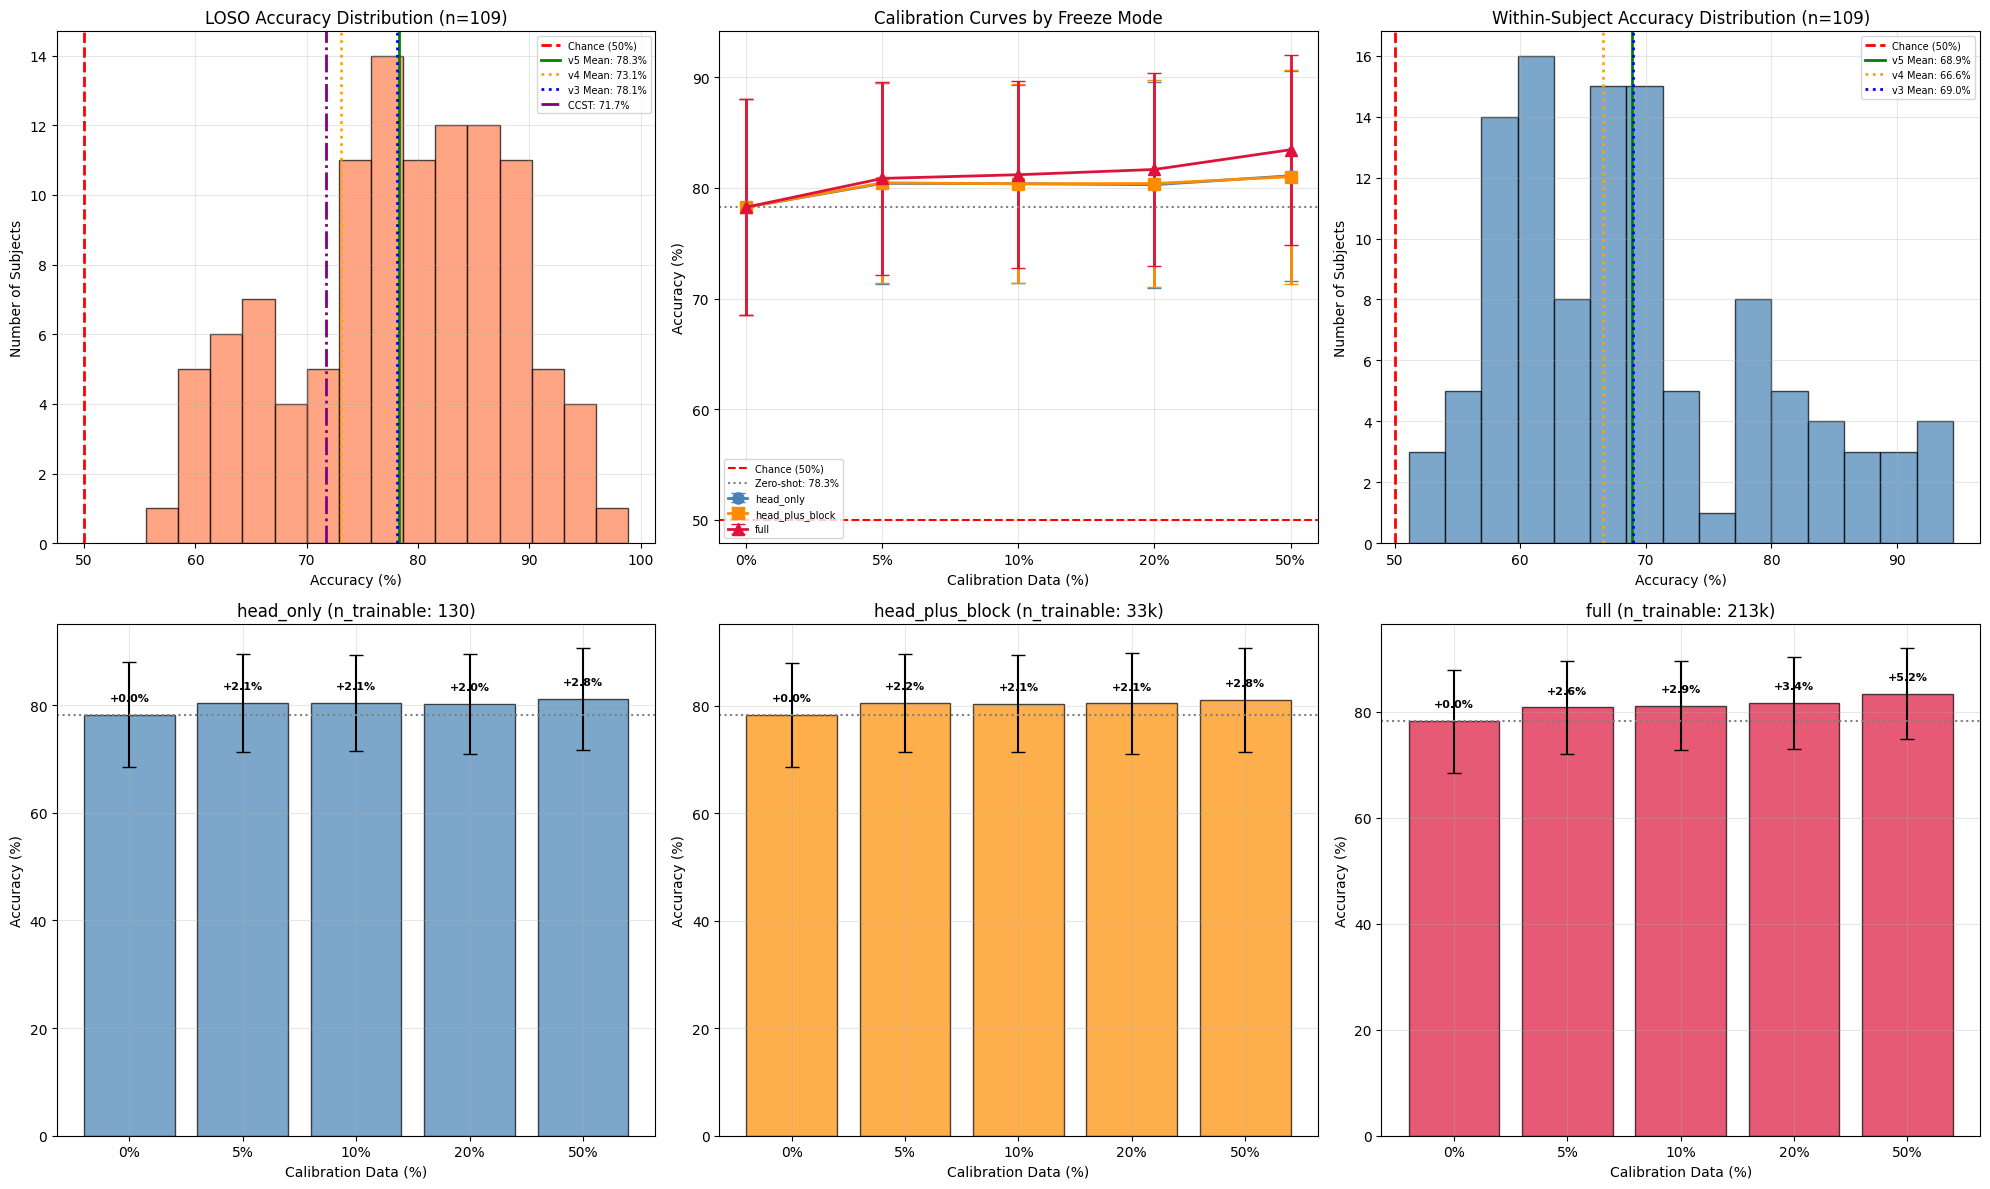

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Row 1: LOSO, Calibration curves, Within-subject 

# 1. LOSO histogram
axes[0, 0].hist(loso_accs * 100, bins=15, color='coral', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=50, color='red', ls='--', lw=2, label='Chance (50%)')
axes[0, 0].axvline(x=loso_accs.mean()*100, color='green', ls='-', lw=2,
                label=f'v5 Mean: {loso_accs.mean()*100:.1f}%')
axes[0, 0].axvline(x=73.1, color='orange', ls=':', lw=2, label='v4 Mean: 73.1%')
axes[0, 0].axvline(x=78.1, color='blue', ls=':', lw=2, label='v3 Mean: 78.1%')
axes[0, 0].axvline(x=71.70, color='purple', ls='-.', lw=2, label='CCST: 71.7%')
axes[0, 0].set_xlabel('Accuracy (%)')
axes[0, 0].set_ylabel('Number of Subjects')
axes[0, 0].set_title(f'LOSO Accuracy Distribution (n={N_SUBJECTS_USED})')
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)

# 2. Calibration curves for each freeze mode
mode_colors = {'head_only': 'steelblue', 'head_plus_block': 'darkorange', 'full': 'crimson'}
mode_markers = {'head_only': 'o', 'head_plus_block': 's', 'full': '^'}

cal_fracs_labels = ['0%'] + [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]

for mode in FREEZE_MODES:
    cal_means = [loso_accs.mean() * 100]
    cal_stds = [loso_accs.std() * 100]

    for frac in CALIBRATION_FRACTIONS:
        frac_key = f'{int(frac*100)}%'
        results = ft_results[mode].get(frac_key, [])
        if results:
            accs = np.array([r['ft_accuracy'] for r in results])
            cal_means.append(accs.mean() * 100)
            cal_stds.append(accs.std() * 100)
        else:
            cal_means.append(np.nan)
            cal_stds.append(np.nan)

    axes[0, 1].errorbar(range(len(cal_fracs_labels)), cal_means, yerr=cal_stds,
                         marker=mode_markers[mode], markersize=8, capsize=5,
                         color=mode_colors[mode], lw=2, label=mode)

axes[0, 1].set_xticks(range(len(cal_fracs_labels)))
axes[0, 1].set_xticklabels(cal_fracs_labels)
axes[0, 1].axhline(y=50, color='red', ls='--', lw=1.5, label='Chance (50%)')
axes[0, 1].axhline(y=loso_accs.mean()*100, color='gray', ls=':', lw=1.5, label=f'Zero-shot: {loso_accs.mean()*100:.1f}%')
axes[0, 1].set_xlabel('Calibration Data (%)')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Calibration Curves by Freeze Mode')
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)

# 3. Within-subject histogram
axes[0, 2].hist(within_accs_v5 * 100, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 2].axvline(x=50, color='red', ls='--', lw=2, label='Chance (50%)')
axes[0, 2].axvline(x=within_accs_v5.mean()*100, color='green', ls='-', lw=2,
                label=f'v5 Mean: {within_accs_v5.mean()*100:.1f}%')
axes[0, 2].axvline(x=66.6, color='orange', ls=':', lw=2, label='v4 Mean: 66.6%')
axes[0, 2].axvline(x=69.0, color='blue', ls=':', lw=2, label='v3 Mean: 69.0%')
axes[0, 2].set_xlabel('Accuracy (%)')
axes[0, 2].set_ylabel('Number of Subjects')
axes[0, 2].set_title(f'Within-Subject Accuracy Distribution (n={N_SUBJECTS_USED})')
axes[0, 2].legend(fontsize=7)
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Per-mode calibration detail 

for col, mode in enumerate(FREEZE_MODES):
    cal_means = [loso_accs.mean() * 100]
    cal_stds = [loso_accs.std() * 100]
    deltas = [0.0]

    for frac in CALIBRATION_FRACTIONS:
        frac_key = f'{int(frac*100)}%'
        results = ft_results[mode].get(frac_key, [])
        if results:
            accs = np.array([r['ft_accuracy'] for r in results])
            improvements = np.array([r['improvement'] for r in results])
            cal_means.append(accs.mean() * 100)
            cal_stds.append(accs.std() * 100)
            deltas.append(improvements.mean() * 100)
        else:
            cal_means.append(np.nan)
            cal_stds.append(np.nan)
            deltas.append(np.nan)

    ax = axes[1, col]
    ax.bar(range(len(cal_fracs_labels)), cal_means,
            yerr=cal_stds, capsize=5, color=mode_colors[mode], alpha=0.7, edgecolor='black')
    ax.axhline(y=loso_accs.mean()*100, color='gray', ls=':', lw=1.5)
    ax.set_xticks(range(len(cal_fracs_labels)))
    ax.set_xticklabels(cal_fracs_labels)
    ax.set_xlabel('Calibration Data (%)')
    ax.set_ylabel('Accuracy (%)')

    # Add delta annotations
    for i, d in enumerate(deltas):
        if not np.isnan(d):
            ax.annotate(f'{d:+.1f}%', (i, cal_means[i]),
                       textcoords="offset points", xytext=(0, 10),
                       ha='center', fontsize=8, fontweight='bold')

    ax.set_title(f'{mode}: Mean={cal_means[1:].__class__(filter(None, cal_means[1:]))}' if False else f'{mode}')
    ax.set_title(f'{mode} (n_trainable: {"130" if mode=="head_only" else "33k" if mode=="head_plus_block" else "213k"})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eegtcnet_v5_physionet_results.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Comparison Table

In [15]:
print('VERSION COMPARISON')
print(f'{"":<25s} {"v2":<15s} {"v3":<15s} {"v4":<15s} {"v5":<15s}')
print(f'{"-"*25} {"-"*15} {"-"*15} {"-"*15} {"-"*15}')
print(f'{"Architecture":<25s} {"EEGNet+TF":<15s} {"Swin+CCST":<15s} {"StdTF+75tok":<15s} {"StdTF+75tok":<15s}')
print(f'{"Channels":<25s} {"16":<15s} {"64":<15s} {"64":<15s} {"64":<15s}')
print(f'{"Tokens":<25s} {"20":<15s} {"37":<15s} {"75":<15s} {"75":<15s}')
print(f'{"Params":<25s} {"72k":<15s} {"210k":<15s} {"210k":<15s} {"213k":<15s}')
print(f'{"Fine-tune strategy":<25s} {"N/A":<15s} {"N/A":<15s} {"full (broken)":<15s} {"layer-freeze":<15s}')
print(f'{"Weight decay":<25s} {"0":<15s} {"0":<15s} {"0":<15s} {"1e-4":<15s}')
print(f'{"-"*25} {"-"*15} {"-"*15} {"-"*15} {"-"*15}')
print(f'{"LOSO":<25s} {"N/A":<15s} {"78.1%":<15s} {"73.1%":<15s} {f"{loso_accs.mean()*100:.1f}%":<15s}')
print(f'{"Within-Subject":<25s} {"65.5%":<15s} {"69.0%":<15s} {"66.6%":<15s} {f"{within_accs_v5.mean()*100:.1f}%":<15s}')
print()

# Fine-tuning comparison by freeze mode
print('Fine-Tuning Results (LOSO + calibration):')
print(f'{"Mode":<18s} {"Cal %":<8s} {"Accuracy":<15s} {"vs Zero-Shot":<15s}')
print(f'{"-"*18} {"-"*8} {"-"*15} {"-"*15}')
print(f'{"zero-shot":<18s} {"—":<8s} {f"{loso_accs.mean()*100:.1f}%":<15s} {"—":<15s}')
for mode in FREEZE_MODES:
    for frac in CALIBRATION_FRACTIONS:
        frac_key = f'{int(frac*100)}%'
        results = ft_results[mode].get(frac_key, [])
        if results:
            accs = np.array([r['ft_accuracy'] for r in results])
            imps = np.array([r['improvement'] for r in results])
            print(f'{mode:<18s} {frac_key:<8s} {f"{accs.mean()*100:.1f}%":<15s} {f"{imps.mean()*100:+.1f}%":<15s}')
        else:
            print(f'{mode:<18s} {frac_key:<8s} {"N/A":<15s} {"N/A":<15s}')
    print()


VERSION COMPARISON
                          v2              v3              v4              v5             
------------------------- --------------- --------------- --------------- ---------------
Architecture              EEGNet+TF       Swin+CCST       StdTF+75tok     StdTF+75tok    
Channels                  16              64              64              64             
Tokens                    20              37              75              75             
Params                    72k             210k            210k            213k           
Fine-tune strategy        N/A             N/A             full (broken)   layer-freeze   
Weight decay              0               0               0               1e-4           
------------------------- --------------- --------------- --------------- ---------------
LOSO                      N/A             78.1%           73.1%           78.3%          
Within-Subject            65.5%           69.0%           66.6%           68.9%  

## 16. Save Results & Final Summary

In [16]:
# Save LOSO results
loso_results_dict = {r['subject']: {'accuracy': float(r['accuracy'])} for r in loso_results}
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v5_loso_results.npy'), loso_results_dict)
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v5_loso_accs.npy'), loso_accs)

# Save fine-tuning results 
ft_save = {}
for mode in FREEZE_MODES:
    ft_save[mode] = {}
    for frac_key, results in ft_results[mode].items():
        ft_save[mode][frac_key] = {
            r['subject']: {
                'ft_accuracy': float(r['ft_accuracy']),
                'zero_shot': float(r['zero_shot']),
                'improvement': float(r['improvement']),
                'n_calib': int(r['n_calib']),
                'freeze_mode': r['freeze_mode'],
            } for r in results
        }
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v5_finetune_results.npy'), ft_save)

# Save within-subject results
within_results_dict = {r['subject']: {
    'accuracy_mean': float(r['accuracy']),
    'accuracy_std': float(r['std']),
    'fold_accs': [float(a) for a in r['fold_accs']],
    'n_trials': int(r['n_trials'])
} for r in within_results_v5}
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v5_within_results.npy'), within_results_dict)
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v5_within_accs.npy'), within_accs_v5)

print('FINAL RESULTS: EEGTCNet v5 on PhysioNet')
print(f'Model: EEGTCNet v5 ({total_params:,} params, Standard Transformer, {model.seq_len} tokens)')
print(f'Dataset: PhysioNet ({len(preprocessed_data)} subjects, {N_CHANNELS}ch, {SFREQ}Hz)')
print(f'Runs: {MI_ME_RUNS} (execution + imagery)')
print(f'')
print(f'LOSO Cross-Subject Accuracy: {loso_accs.mean()*100:.1f}% +/- {loso_accs.std()*100:.1f}%')
print(f'  v4 comparison (20 subj): 73.1% +/- 8.5%')
print(f'  v3 comparison (109 subj): 78.1%')
print(f'  CCST benchmark: 71.70%')
print(f'  Min: {loso_accs.min()*100:.1f}%, Max: {loso_accs.max()*100:.1f}%')
print(f'  Above chance (>50%): {np.sum(loso_accs > 0.5)}/{len(loso_results)}')
print(f'')
print(f'Fine-Tuning by Freeze Mode:')
for mode in FREEZE_MODES:
    print(f'  {mode}:')
    for frac in CALIBRATION_FRACTIONS:
        frac_key = f'{int(frac*100)}%'
        results = ft_results[mode].get(frac_key, [])
        if results:
            accs = np.array([r['ft_accuracy'] for r in results])
            imps = np.array([r['improvement'] for r in results])
            print(f'    {frac_key}: {accs.mean()*100:.1f}% +/- {accs.std()*100:.1f}% (delta={imps.mean()*100:+.1f}%)')
        else:
            print(f'    {frac_key}: N/A')
print(f'')
print(f'Within-Subject Accuracy (5-Fold CV): {within_accs_v5.mean()*100:.1f}% +/- {within_accs_v5.std()*100:.1f}%')
print(f'  v4 comparison (20 subj): 66.6% +/- 9.7%')
print(f'  v3 comparison (109 subj): 69.0% +/- 10.7%')
print(f'  Min: {within_accs_v5.min()*100:.1f}%, Max: {within_accs_v5.max()*100:.1f}%')
print(f'')
print(f'All results saved to: {SAVE_DIR}')


FINAL RESULTS: EEGTCNet v5 on PhysioNet
Model: EEGTCNet v5 (213,298 params, Standard Transformer, 75 tokens)
Dataset: PhysioNet (109 subjects, 64ch, 160Hz)
Runs: [3, 4, 7, 8, 11, 12] (execution + imagery)

LOSO Cross-Subject Accuracy: 78.3% +/- 9.7%
  v4 comparison (20 subj): 73.1% +/- 8.5%
  v3 comparison (109 subj): 78.1%
  CCST benchmark: 71.70%
  Min: 55.6%, Max: 98.9%
  Above chance (>50%): 109/109

Fine-Tuning by Freeze Mode:
  head_only:
    5%: 80.4% +/- 9.1% (delta=+2.1%)
    10%: 80.4% +/- 9.0% (delta=+2.1%)
    20%: 80.3% +/- 9.3% (delta=+2.0%)
    50%: 81.1% +/- 9.5% (delta=+2.8%)
  head_plus_block:
    5%: 80.5% +/- 9.0% (delta=+2.2%)
    10%: 80.4% +/- 9.0% (delta=+2.1%)
    20%: 80.4% +/- 9.3% (delta=+2.1%)
    50%: 81.0% +/- 9.7% (delta=+2.8%)
  full:
    5%: 80.9% +/- 8.7% (delta=+2.6%)
    10%: 81.2% +/- 8.4% (delta=+2.9%)
    20%: 81.7% +/- 8.7% (delta=+3.4%)
    50%: 83.4% +/- 8.6% (delta=+5.2%)

Within-Subject Accuracy (5-Fold CV): 68.9% +/- 10.3%
  v4 comparison (